In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 8 — Solving the model numerically, which is how PBPK is done

Everything so far used a CLOSED FORM: someone solved the differential
equation once, by hand, and we evaluated the formula. That works for one
compartment, for two, and for almost nothing else.

A PBPK model has an equation per organ, blood flows coupling them, and
often a saturable term. It has no closed form. You write down dC/dt and
hand it to a numerical integrator.

This lesson makes that switch on models you already trust, so you can
check the machinery against a known answer before relying on it. Then it
does something the closed form cannot: saturable elimination.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

import plotting as P
from tk import load, iv_1comp, iv_2comp, half_life

P.setup()
DOSE = 10.0

## A. One compartment, written as an ODE

In [3]:
def rhs_1comp(t, state, k):
    """Right-hand side: given the current state, return its derivative.

    This IS the model. Everything else -- the exponential, the half-life
    formula -- is a consequence a mathematician worked out once.

    `state` is a list even though there is one compartment here, because
    solve_ivp always works with vectors. Keeping that convention from
    the start means nothing changes when you add organs.
    """
    C, = state
    return [-k * C]


def solve_1comp(t_eval, dose, Vd, k, **kw):
    """Integrate from t=0 to max(t_eval), reporting at t_eval.

    The IV bolus is an INITIAL CONDITION, not an input term: the whole
    dose is present at t=0, so C(0) = dose/Vd.
    """
    sol = solve_ivp(rhs_1comp, (0.0, float(np.max(t_eval))), [dose / Vd],
                    t_eval=t_eval, args=(k,), dense_output=True, **kw)
    assert sol.success, sol.message
    return sol.y[0]


print("A. Does the numerical solution match the formula?\n")
t = np.linspace(0, 60, 13)
Vd, k = 0.18, 0.06
exact = iv_1comp(t, DOSE, Vd, k)

print(f"   {'tolerance':>12s} {'max relative error':>20s} {'RHS evaluations':>17s}")
for rtol in [1e-3, 1e-6, 1e-9, 1e-12]:
    sol = solve_ivp(rhs_1comp, (0, 60), [DOSE / Vd], t_eval=t, args=(k,),
                    rtol=rtol, atol=rtol * 1e-3)
    err = np.max(np.abs(sol.y[0] / exact - 1))
    print(f"   {rtol:12.0e} {err:20.2e} {sol.nfev:17d}")

A. Does the numerical solution match the formula?

      tolerance   max relative error   RHS evaluations
          1e-03             1.93e-03                38
          1e-06             9.48e-07               110
          1e-09             7.83e-10               380
          1e-12             7.45e-13              1472


The integrator is not approximate in the way a coarse grid is: you
ASK for an accuracy and it adapts its step size to deliver it, at the
cost of more evaluations. At rtol=1e-9 it agrees with the analytical
answer to ten significant figures.

Two habits worth forming now:
- always check `sol.success`; a silent failure returns garbage
- always verify a new ODE against a case you can solve by hand,
  exactly as this section does. When you later write a PBPK model
  with nine compartments, set all the exchange rates to zero and
  check it reduces to one compartment.

## B. Two compartments -- where hand-solving stops being fun

In [4]:
def rhs_2comp(t, state, k10, k12, k21):
    """Two coupled ODEs, in AMOUNTS (mg/kg) rather than concentrations.

    Amounts are the safer currency: mass balance is then just
    "what leaves A1 arrives in A2", with no volumes to get wrong.
    Convert to concentration only at the end.
    """
    A1, A2 = state
    return [-(k10 + k12) * A1 + k21 * A2,
            k12 * A1 - k21 * A2]


print("B. Two compartments, numerically vs the analytical solution\n")
V1, k10, k12, k21 = 0.14, 0.10, 0.50, 0.30
sol = solve_ivp(rhs_2comp, (0, 60), [DOSE, 0.0], t_eval=t,
                args=(k10, k12, k21), rtol=1e-10, atol=1e-12)
num = sol.y[0] / V1
ana = iv_2comp(t, DOSE, V1, k10, k12, k21)
print(f"   max relative error: {np.max(np.abs(num / ana - 1)):.2e}")

total = sol.y[0] + sol.y[1]
print(f"   mass check: dose {DOSE:g} mg/kg in, "
      f"{total[0]:.6f} at t=0, {total[-1]:.6f} left at t=60")

B. Two compartments, numerically vs the analytical solution

   max relative error: 2.86e-11
   mass check: dose 10 mg/kg in, 10.000000 at t=0, 1.150897 left at t=60


Notice the second check. In an ODE model you can always account for
where the mass went, and you should: a conservation error is the
fastest way to catch a sign slip or a missing term. Here the only
loss is k10*A1, so the total falls monotonically. In a PBPK model
with ten organs, this check is not optional.

## C. Something with no closed form: saturable elimination

In [5]:
def rhs_saturable(t, state, Vd, Vmax, Km):
    """Michaelis-Menten elimination instead of a fixed rate constant.

        dC/dt = -Vmax*C / (Km + C) / Vd

    When C << Km this is first order with k = Vmax/(Km*Vd), and the
    curve is the exponential you already know. When C >> Km the kidney's
    transporters are saturated, elimination runs flat out at Vmax, and
    the fall is LINEAR, not exponential.

    There is no analytical C(t) for this. That is the point: this is the
    mechanism the whole dose-dependence question in ../pfas_dose is
    about, and you can only study it numerically.
    """
    C, = state
    return [-Vmax * C / (Km + C) / Vd]


print("C. Saturable elimination -- no closed form exists\n")
Vd_s, Vmax, Km = 0.18, 0.30, 5.0        # mg/kg/day, mg/L
# 100 mg/kg takes far longer than 120 days to halve, so integrate long
# enough that every dose actually reaches its half-life inside the window.
grid = np.linspace(0, 500, 5000)
print(f"   Vmax = {Vmax} mg/kg/day, Km = {Km} mg/L, Vd = {Vd_s} L/kg")
print(f"   low-dose limit: k -> Vmax/(Km*Vd) = {Vmax/(Km*Vd_s):.4f} /day, "
      f"half-life {half_life(Vmax/(Km*Vd_s)):.2f} d\n")

print(f"   {'dose (mg/kg)':>13s} {'C(0)':>8s} {'C(0)/Km':>9s} "
      f"{'apparent t1/2 (d)':>18s}")
sat = {}
for d in [0.1, 1.0, 10.0, 100.0]:
    s = solve_ivp(rhs_saturable, (0, grid[-1]), [d / Vd_s], t_eval=grid,
                  args=(Vd_s, Vmax, Km), rtol=1e-9, atol=1e-12)
    C = s.y[0]
    sat[d] = C
    # apparent half-life measured the way an experimenter would: the time
    # for the concentration to fall by half from its starting value
    below = np.flatnonzero(C <= C[0] / 2)
    t_half = grid[below[0]] if below.size else np.nan
    shown = f"{t_half:.2f}" if np.isfinite(t_half) else f"> {grid[-1]:.0f}"
    print(f"   {d:13g} {C[0]:8.2f} {C[0]/Km:9.1f} {shown:>18s}")

C. Saturable elimination -- no closed form exists

   Vmax = 0.3 mg/kg/day, Km = 5.0 mg/L, Vd = 0.18 L/kg
   low-dose limit: k -> Vmax/(Km*Vd) = 0.3333 /day, half-life 2.08 d

    dose (mg/kg)     C(0)   C(0)/Km  apparent t1/2 (d)
             0.1     0.56       0.1               2.30
               1     5.56       1.1               3.80
              10    55.56      11.1              18.80
             100   555.56     111.1             168.83


The SAME chemical, the same kidney, four different half-lives. At
0.1 mg/kg the transporters are far from saturated and you recover the
first-order half-life. At 100 mg/kg they are swamped, elimination
runs at its ceiling, and the apparent half-life is many times longer.

This is the mechanism behind the project's dose question -- but read
the sign carefully. Saturation makes clearance FALL as dose rises,
so half-life RISES with dose. Our rat data showed the opposite:
clearance rose with dose (beta = +0.11), half-life fell. Simple
saturable reabsorption of the kind modelled here cannot produce
that; something else (induction of an efflux transporter, or a
saturable REABSORPTION step that returns chemical to the blood) is
needed. See ../pfas_dose/RESULTS.md.

## D. Fitting an ODE model -- the pattern you will reuse for PBPK

In [6]:
mk = load("PFOA_Male_primate")
one = mk[(mk.animal_id == 2054) & (mk.conc_mgL > 0)].sort_values("time_d")
t_obs, C_obs = one.time_d.values, one.conc_mgL.values


def predict_2comp(t_, ln_V1, ln_k10, ln_k12, ln_k21):
    """Integrate, then return log concentration at the observed times.

    The optimiser calls this hundreds of times, so the integration has
    to be inside the objective. That is the only structural difference
    from lesson 04, and it is the same difference for a PBPK model --
    just with a slower right-hand side.
    """
    V1_, k10_, k12_, k21_ = np.exp([ln_V1, ln_k10, ln_k12, ln_k21])
    s = solve_ivp(rhs_2comp, (0.0, float(t_.max())), [DOSE, 0.0],
                  t_eval=t_, args=(k10_, k12_, k21_), rtol=1e-8, atol=1e-10)
    if not s.success:
        return np.full_like(t_, 1e3)        # steer the optimiser away
    return np.log(np.maximum(s.y[0] / V1_, 1e-12))


p0 = np.log([0.14, 0.08, 0.4, 0.2])
popt, _ = curve_fit(predict_2comp, t_obs, np.log(C_obs), p0=p0, maxfev=20000)
V1f, k10f, k12f, k21f = np.exp(popt)
sm = k10f + k12f + k21f
disc = np.sqrt(sm ** 2 - 4 * k10f * k21f)
alpha, beta = (sm + disc) / 2, (sm - disc) / 2

print(f"   V1  = {V1f:.4f} L/kg      k10 = {k10f:.4f} /day")
print(f"   k12 = {k12f:.4f} /day     k21 = {k21f:.4f} /day")
print(f"   fast half-life  (alpha) = {half_life(alpha):6.2f} d")
print(f"   slow half-life  (beta)  = {half_life(beta):6.2f} d")
print(f"   Vss = V1*(1+k12/k21)    = {V1f*(1+k12f/k21f):.4f} L/kg")
print(f"   CL  = V1*k10            = {V1f*k10f:.5f} L/kg/day")

   V1  = 0.1261 L/kg      k10 = 0.1398 /day
   k12 = 0.0156 /day     k21 = 0.0506 /day
   fast half-life  (alpha) =   4.26 d
   slow half-life  (beta)  =  15.94 d
   Vss = V1*(1+k12/k21)    = 0.1651 L/kg
   CL  = V1*k10            = 0.01763 L/kg/day


Compare with the Bayesian two-compartment fit in lesson 07, which
used all three monkeys hierarchically:


```text
quantity          here (monkey 2054, NLS)   lesson 07 (population)
terminal t1/2     15.9 d                    19.8 d  (95% CI 11-31)
Vss               0.165 L/kg                0.197   (0.139-0.261)
CL                0.0176 L/kg/day           0.011   (0.004-0.019)
```

All three land inside the population intervals, which is the check
you want: two different methods, two different objectives, one
answer. They are not IDENTICAL, and should not be -- this is one
animal fitted alone, and lesson 06 showed the three monkeys differ
threefold. Agreement to within the interval is the standard to hold
a new implementation to, not agreement to three decimals.

## E. Figures

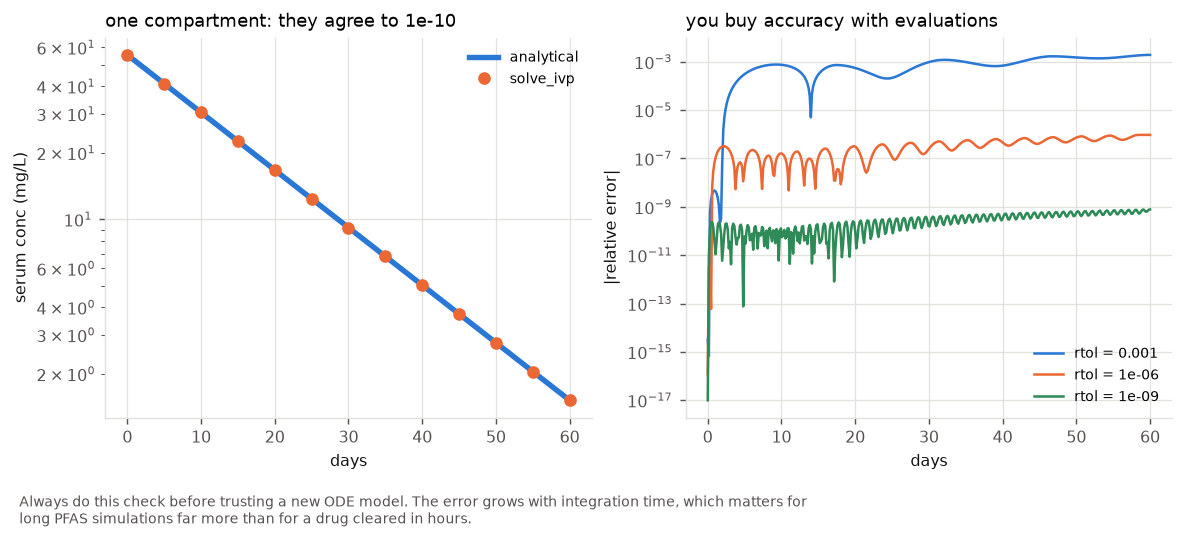

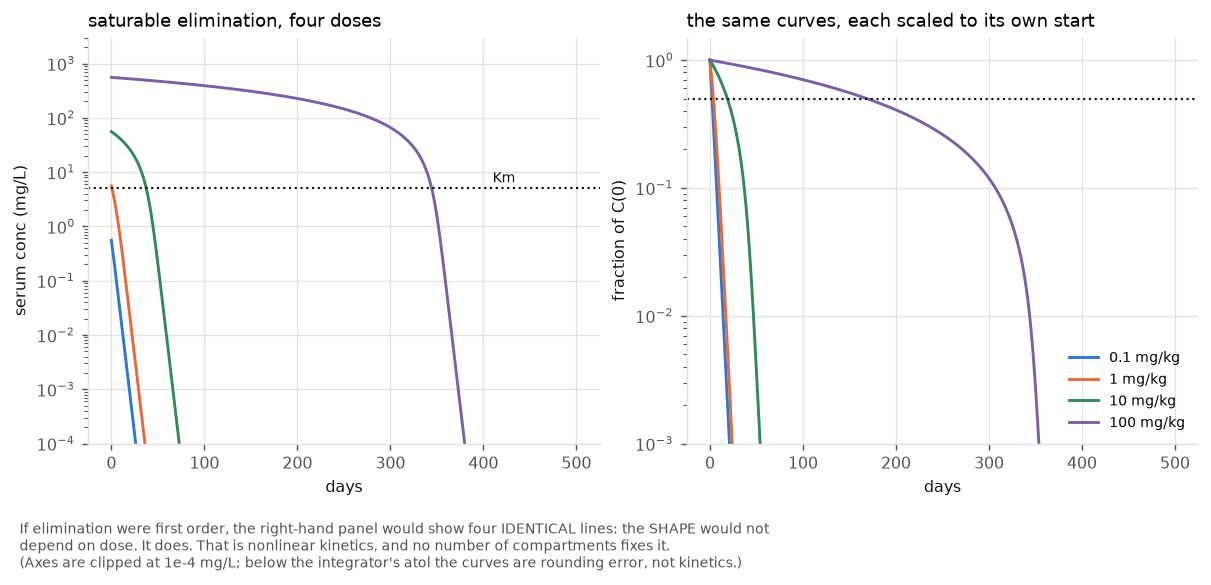

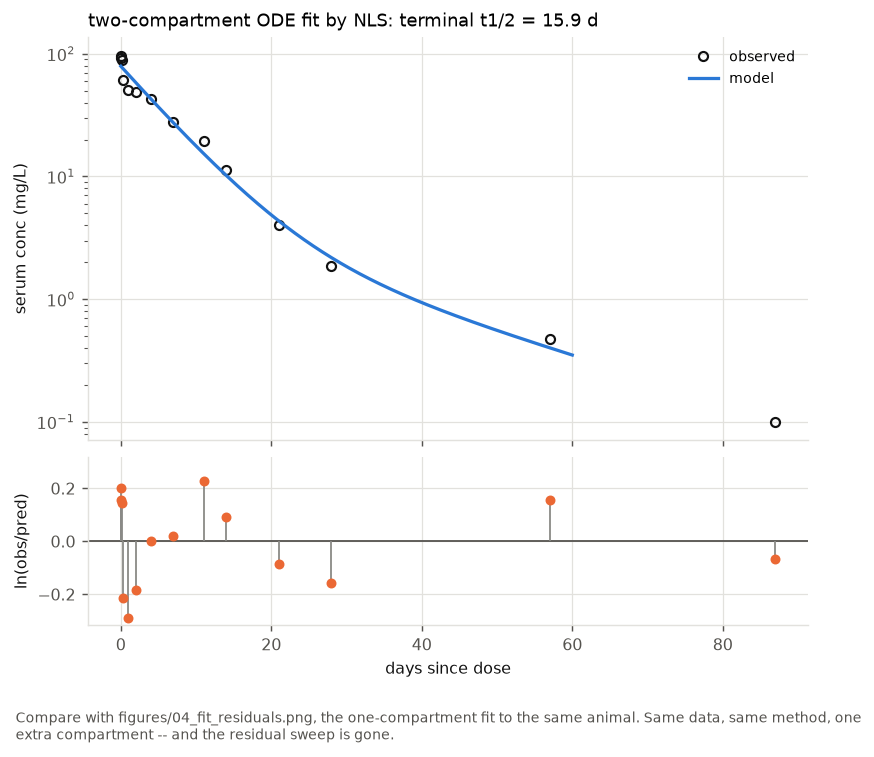

'/home/user/chiu__2022_rerun/tk_learning/figures/08_ode_fit.png'

In [7]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.0, 3.6), constrained_layout=True)
tt = np.linspace(0.01, 60, 400)
a.plot(tt, iv_1comp(tt, DOSE, Vd, k), color=P.BLUE, lw=3.0, label="analytical")
a.plot(t, solve_1comp(t, DOSE, Vd, k, rtol=1e-9, atol=1e-12), "o",
       color=P.ORANGE, ms=6, label="solve_ivp")
a.set(yscale="log", xlabel="days", ylabel="serum conc (mg/L)")
a.set_title("one compartment: they agree to 1e-10")
a.legend()
for rtol, col in zip([1e-3, 1e-6, 1e-9], P.CYCLE):
    s = solve_ivp(rhs_1comp, (0, 60), [DOSE / Vd], t_eval=tt, args=(k,),
                  rtol=rtol, atol=rtol * 1e-3)
    b.plot(tt, np.abs(s.y[0] / iv_1comp(tt, DOSE, Vd, k) - 1) + 1e-17,
           color=col, lw=1.4, label=f"rtol = {rtol:g}")
b.set(yscale="log", xlabel="days", ylabel="|relative error|")
b.set_title("you buy accuracy with evaluations")
b.legend()
P.save(fig, "08_numerical_vs_analytical.png",
       "Always do this check before trusting a new ODE model. The error "
       "grows with integration time, which matters for\nlong PFAS "
       "simulations far more than for a drug cleared in hours.")

fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
for (d, C), col in zip(sat.items(), P.CYCLE):
    a.plot(grid, C, color=col, lw=1.6, label=f"{d:g} mg/kg")
    b.plot(grid, C / C[0], color=col, lw=1.6, label=f"{d:g} mg/kg")
a.axhline(Km, color=P.INK, ls=":", lw=1.2)
a.annotate("Km", (grid[-1] * 0.82, Km * 1.3), color=P.INK, fontsize=8)
a.set(yscale="log", xlabel="days", ylabel="serum conc (mg/L)",
      ylim=(1e-4, 3e3))
a.set_title("saturable elimination, four doses")
b.axhline(0.5, color=P.INK, ls=":", lw=1.2)
b.set(yscale="log", xlabel="days", ylabel="fraction of C(0)", ylim=(1e-3, 1.5))
b.set_title("the same curves, each scaled to its own start")
b.legend(fontsize=8)
P.save(fig, "08_saturation.png",
       "If elimination were first order, the right-hand panel would show "
       "four IDENTICAL lines: the SHAPE would not\ndepend on dose. It "
       "does. That is nonlinear kinetics, and no number of compartments "
       "fixes it.\n(Axes are clipped at 1e-4 mg/L; below the "
       "integrator's atol the curves are rounding error, not kinetics.)")

P.fit_and_residuals(
    t_obs, C_obs, tt,
    np.exp(predict_2comp(tt, *popt)), np.exp(predict_2comp(t_obs, *popt)),
    title=f"two-compartment ODE fit by NLS: terminal t1/2 = {half_life(beta):.1f} d",
    name="08_ode_fit.png",
    note="Compare with figures/04_fit_residuals.png, the one-compartment "
         "fit to the same animal. Same data, same method, one\nextra "
         "compartment -- and the residual sweep is gone.")

### Questions

1. In section A, why does asking for rtol=1e-12 cost more function evaluations than rtol=1e-3? What is the integrator actually doing differently?
1. Section B tracks amounts, not concentrations. Rewrite rhs_2comp in concentrations and you need V1 and V2 explicitly. Which form would you rather debug in a model with ten organs?
1. In section C, the apparent half-life RISES with dose. Our rat data showed it FALLING. Sketch a mechanism that gives the falling sign. (Hint: what if the saturating transporter moves chemical back INTO the blood rather than out of it?)
1. Section D integrates inside the objective function. If one integration takes 10 ms and the optimiser needs 500 evaluations, how long is the fit? Now make it Bayesian with 8000 MCMC draws. What does that tell you about why PBPK models are fitted the way they are?

### Exercises

1. Add an oral dose to rhs_1comp: a second state for the gut, with dA_gut/dt = -ka*A_gut and the blood gaining ka*A_gut/Vd. Check it against tk.oral_1comp.
1. Add a CONTINUOUS input (drinking water) instead of a bolus: dC/dt = DWI*DWC/Vd - k*C, starting from C(0) = 0. Run it for 30 years. You have now built Chiu's human model (../model.py) -- compare your steady state to DWI*DWC/(k*Vd).
1. Repeat exercise b but make DWC drop to zero at year 10, as happens when a town switches water supply. This is exactly the kind of question a closed form cannot answer and an ODE can.
1. Take the saturable model from section C and give it a continuous input. Is there still a steady state if the input exceeds Vmax? What does the model do instead, and is that physically sensible?